# Multi-Criteria Evaluation of Clustering Methods

Evaluates DBSCAN, HDBSCAN, KDE and Percolation analysis across three criteria:

1. **DBCV (Density-Based Clustering Validity)** — Moulavi et al. (2014). Applicable to DBSCAN and HDBSCAN only.
   Measures how well within-cluster density connectivity compares to between-cluster separation. Range: [-1, 1]; higher is better.
   KDE and Percolation produce fundamentally different output types (continuous surface; connectivity typology)
   that do not map cleanly onto DBCV's assumptions, so these are marked N/A.

2. **Temple Discrimination Ratio (TDR)** — 
   Defined as: median(dist_to_temple | background) / median(dist_to_temple | clustered).
   Higher ratio = clustered mounds are substantially closer to temples than unclustered mounds.
   Applicable to all four methods.

3. **Parameter Sensitivity (CV%)** — coefficient of variation of % clustered across tested parameter settings.
   Lower = more stable results across parameter choices. Applicable to DBSCAN, HDBSCAN, and KDE.
   Percolation's critical radius is empirically derived rather than user-selected, so CV is not applicable
   in the same sense; it is excluded from this criterion with that justification.

In [1]:
import numpy as np
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import hdbscan
from hdbscan import validity_index as dbcv
from sklearn.cluster import DBSCAN
from sklearn.neighbors import KernelDensity
import networkx as nx
from scipy.spatial import cKDTree
from scipy.signal import savgol_filter
import warnings
warnings.filterwarnings('ignore')

OUT = '/Users/amber/Documents/M Thesis/Notebooks/Evaluation/'

print('Imports OK')

Imports OK


## 1. Load Data and Compute Temple Distances

In [2]:
features  = gpd.read_file('/Users/amber/Documents/M Thesis/Data/QGIS/isaura_features.gpkg')
parcel    = gpd.read_file('/Users/amber/Documents/M Thesis/Data/QGIS/08_isaura_extent.shp')

mounds    = features[features['type'] == 'mound'].copy()
temples   = features[features['type'] == 'temple'].copy()

centroids = mounds.geometry.centroid
x = centroids.x.values
y = centroids.y.values
coords = np.column_stack([x, y])

tx = temples.geometry.centroid.x.values
ty = temples.geometry.centroid.y.values

temple_kd         = cKDTree(np.column_stack([tx, ty]))
dist_temple, _    = temple_kd.query(coords, k=1)

N = len(coords)
print(f'n = {N}, temples = {len(temples)}')
print(f'Overall median mound-temple distance: {np.median(dist_temple):.0f} m')

n = 2671, temples = 192
Overall median mound-temple distance: 515 m


## 2. DBCV Scores

In [3]:
# ── DBSCAN DBCV ─────────────────────────────────────────────────────
DBSCAN_EPS   = [120, 200, 360]
DBSCAN_LABELS = {}
DBSCAN_DBCV   = {}

for eps in DBSCAN_EPS:
    db     = DBSCAN(eps=eps, min_samples=4, algorithm='ball_tree',
                    metric='euclidean').fit(coords)
    labels = db.labels_
    DBSCAN_LABELS[eps] = labels
    n_cl = len(set(labels)) - (1 if -1 in labels else 0)
    n_no = (labels == -1).sum()
    score = dbcv(coords, labels, metric='euclidean')
    DBSCAN_DBCV[eps] = score
    print(f'DBSCAN eps={eps:3d}m: {n_cl:3d} clusters, {n_no:,} noise '
          f'({100*n_no/N:.1f}%)  DBCV = {score:.4f}')

DBSCAN eps=120m:  74 clusters, 1,800 noise (67.4%)  DBCV = 0.0799
DBSCAN eps=200m:  97 clusters, 749 noise (28.0%)  DBCV = -0.0605
DBSCAN eps=360m:  23 clusters, 118 noise (4.4%)  DBCV = -0.6111


In [4]:
# ── HDBSCAN DBCV ────────────────────────────────────────────────────
MCS_VALUES   = [4, 10, 20]
HDBSCAN_CL   = {}
HDBSCAN_DBCV = {}

for mcs in MCS_VALUES:
    cl = hdbscan.HDBSCAN(min_cluster_size=mcs, min_samples=4, metric='euclidean',
                          cluster_selection_method='eom', prediction_data=True,
                          gen_min_span_tree=True)
    cl.fit(coords)
    HDBSCAN_CL[mcs]   = cl
    labels = cl.labels_
    n_cl = len(set(labels)) - (1 if -1 in labels else 0)
    n_no = (labels == -1).sum()
    # Use relative_validity_ (computed from MST, consistent with Campello et al. 2015)
    rv  = cl.relative_validity_
    # Cross-check with validity_index
    vi  = dbcv(coords, labels, metric='euclidean')
    HDBSCAN_DBCV[mcs] = rv
    print(f'HDBSCAN mc={mcs:2d}: {n_cl:3d} clusters, {n_no:,} noise '
          f'({100*n_no/N:.1f}%)  DBCV(rel) = {rv:.4f}  DBCV(vi) = {vi:.4f}')

HDBSCAN mc= 4: 112 clusters, 1,021 noise (38.2%)  DBCV(rel) = 0.1945  DBCV(vi) = 0.1796
HDBSCAN mc=10:  55 clusters, 1,112 noise (41.6%)  DBCV(rel) = 0.2752  DBCV(vi) = 0.0839
HDBSCAN mc=20:  28 clusters, 1,251 noise (46.8%)  DBCV(rel) = 0.2434  DBCV(vi) = 0.0962


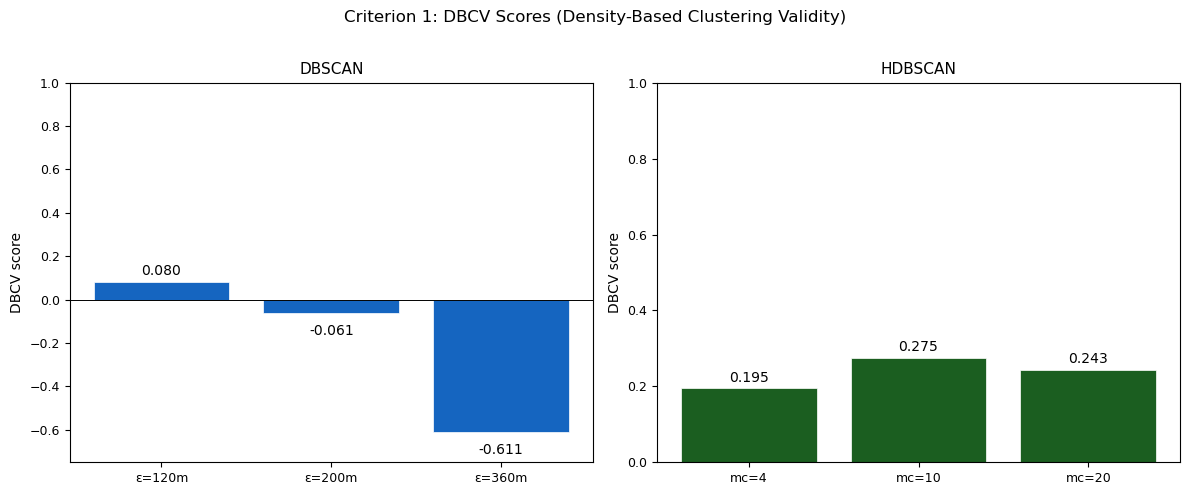

Saved: evaluation_dbcv.png


In [8]:
# ── Fig: DBCV scores ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# DBSCAN
ax = axes[0]
labels_str = [f'ε={e}m' for e in DBSCAN_EPS]
scores     = [DBSCAN_DBCV[e] for e in DBSCAN_EPS]
colours    = ['#B0BEC5' if np.isnan(s) else '#1565C0' for s in scores]
bars = ax.bar(labels_str, [0 if np.isnan(s) else s for s in scores],
              color=colours, edgecolor='white', linewidth=0.5)
for bar, score in zip(bars, scores):
    label = 'NaN' if np.isnan(score) else f'{score:.3f}'
    h = bar.get_height()
    ypos = h + 0.02 if h >= 0 else h - 0.05
    va   = 'bottom' if h >= 0 else 'top'
    ax.text(bar.get_x() + bar.get_width()/2, ypos,
            label, ha='center', va=va, fontsize=10)
ax.set_ylim(-0.75, 1.0)
ax.set_ylabel('DBCV score', fontsize=10)
ax.set_title('DBSCAN', fontsize=11)
ax.axhline(0, color='black', linewidth=0.7)
ax.tick_params(labelsize=9)

# HDBSCAN
ax = axes[1]
labels_str2 = [f'mc={m}' for m in MCS_VALUES]
scores2     = [HDBSCAN_DBCV[m] for m in MCS_VALUES]
ax.bar(labels_str2, scores2, color='#1B5E20', edgecolor='white', linewidth=0.5)
for i, (s, m) in enumerate(zip(scores2, MCS_VALUES)):
    ax.text(i, s + 0.01, f'{s:.3f}', ha='center', va='bottom', fontsize=10)
ax.set_ylim(0, 1.0)
ax.set_ylabel('DBCV score', fontsize=10)
ax.set_title('HDBSCAN', fontsize=11)
ax.axhline(0, color='black', linewidth=0.7)
ax.tick_params(labelsize=9)

plt.suptitle('Criterion 1: DBCV Scores (Density-Based Clustering Validity)\n', fontsize=12)
plt.tight_layout()
plt.savefig(OUT + 'evaluation_dbcv.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: evaluation_dbcv.png')

## 3. Temple Discrimination Ratio (TDR)

**Definition:** TDR = median(dist_temple | background) / median(dist_temple | clustered)

A ratio of 1.0 means the method does not distinguish temple-proximate mounds from temple-distant
mounds. Higher values indicate that clustered/in-zone mounds are systematically closer to temples
than mounds left outside the clustering. .

Applied to all four methods. For KDE, 'clustered' = mounds in the high-density exceedance zone;
for Percolation, 'clustered' = mounds in the giant component at r_c.

In [9]:
def tdr(is_cluster, dist):
    """Temple Discrimination Ratio: median background / median clustered."""
    med_cl = np.median(dist[is_cluster])
    med_bg = np.median(dist[~is_cluster])
    return med_bg / med_cl if med_cl > 0 else np.nan

# DBSCAN
print('DBSCAN TDR:')
dbscan_tdr = {}
for eps in DBSCAN_EPS:
    labels    = DBSCAN_LABELS[eps]
    is_cl     = labels != -1
    ratio     = tdr(is_cl, dist_temple)
    dbscan_tdr[eps] = ratio
    print(f'  eps={eps}m: med_cluster={np.median(dist_temple[is_cl]):.0f}m  '
          f'med_noise={np.median(dist_temple[~is_cl]):.0f}m  TDR={ratio:.3f}')

DBSCAN TDR:
  eps=120m: med_cluster=198m  med_noise=718m  TDR=3.629
  eps=200m: med_cluster=350m  med_noise=969m  TDR=2.769
  eps=360m: med_cluster=483m  med_noise=1276m  TDR=2.643


In [10]:
# HDBSCAN
print('HDBSCAN TDR:')
hdbscan_tdr = {}
for mcs in MCS_VALUES:
    labels = HDBSCAN_CL[mcs].labels_
    is_cl  = labels != -1
    ratio  = tdr(is_cl, dist_temple)
    hdbscan_tdr[mcs] = ratio
    print(f'  mc={mcs}: med_cluster={np.median(dist_temple[is_cl]):.0f}m  '
          f'med_noise={np.median(dist_temple[~is_cl]):.0f}m  TDR={ratio:.3f}')

HDBSCAN TDR:
  mc=4: med_cluster=421m  med_noise=638m  TDR=1.516
  mc=10: med_cluster=393m  med_noise=665m  TDR=1.691
  mc=20: med_cluster=384m  med_noise=621m  TDR=1.616


In [11]:
# KDE — re-run exceedance zone assignments
from sklearn.neighbors import KernelDensity

BANDWIDTHS  = [120, 360, 500]
PERCENTILES = [75, 90, 95]

# Evaluation grid (200x200 as in section 7.1)
xg = np.linspace(x.min(), x.max(), 200)
yg = np.linspace(y.min(), y.max(), 200)
XX, YY = np.meshgrid(xg, yg)
grid_pts = np.column_stack([XX.ravel(), YY.ravel()])

print('KDE TDR:')
kde_tdr  = {}   # key: (bw, pct)
kde_pct  = {}   # key: (bw, pct) -> % in zone

for bw in BANDWIDTHS:
    kde = KernelDensity(bandwidth=bw, kernel='gaussian',
                        algorithm='ball_tree').fit(coords)
    log_dens  = kde.score_samples(grid_pts)
    dens_grid = np.exp(log_dens)

    # Assign each mound to nearest grid cell
    grid_kd   = cKDTree(grid_pts)
    _, idx    = grid_kd.query(coords, k=1)
    mound_dens = dens_grid[idx]

    for pct in PERCENTILES:
        threshold = np.percentile(dens_grid, pct)
        in_zone   = mound_dens >= threshold
        ratio     = tdr(in_zone, dist_temple)
        kde_tdr[(bw, pct)]  = ratio
        kde_pct[(bw, pct)]  = 100 * in_zone.mean()
        print(f'  h={bw}m, p{pct}: in_zone={in_zone.sum()} ({in_zone.mean()*100:.1f}%)  '
              f'TDR={ratio:.3f}')

KDE TDR:
  h=120m, p75: in_zone=2666 (99.8%)  TDR=2.209
  h=120m, p90: in_zone=1810 (67.8%)  TDR=2.742
  h=120m, p95: in_zone=1205 (45.1%)  TDR=3.543
  h=360m, p75: in_zone=2220 (83.1%)  TDR=2.740
  h=360m, p90: in_zone=1406 (52.6%)  TDR=3.535
  h=360m, p95: in_zone=937 (35.1%)  TDR=4.589
  h=500m, p75: in_zone=2140 (80.1%)  TDR=2.892
  h=500m, p90: in_zone=1338 (50.1%)  TDR=3.687
  h=500m, p95: in_zone=891 (33.4%)  TDR=4.537


In [12]:
# Percolation — re-run to get giant component at r_c
R_VALS = np.logspace(np.log10(50), np.log10(3000), 200)
kd_tree = cKDTree(coords)
S_vals  = []
for r in R_VALS:
    pairs = list(kd_tree.query_pairs(r))
    G = nx.Graph(); G.add_nodes_from(range(N)); G.add_edges_from(pairs)
    comps = list(nx.connected_components(G))
    S_vals.append(max(len(c) for c in comps) / N if comps else 0)

S_sm = savgol_filter(np.array(S_vals), window_length=11, polyorder=3)
rc_idx = np.argmax(np.gradient(S_sm, R_VALS))
r_c    = R_VALS[rc_idx]
print(f'r_c = {r_c:.0f} m')

pairs_rc = list(kd_tree.query_pairs(r_c))
G_rc = nx.Graph(); G_rc.add_nodes_from(range(N)); G_rc.add_edges_from(pairs_rc)
comps_rc = sorted(nx.connected_components(G_rc), key=len, reverse=True)
giant_rc = set(comps_rc[0])
in_giant = np.array([i in giant_rc for i in range(N)])

perc_tdr = tdr(in_giant, dist_temple)
print(f'Percolation: giant={in_giant.sum()} ({in_giant.mean()*100:.1f}%)  TDR={perc_tdr:.3f}')

r_c = 325 m
Percolation: giant=2009 (75.2%)  TDR=2.435


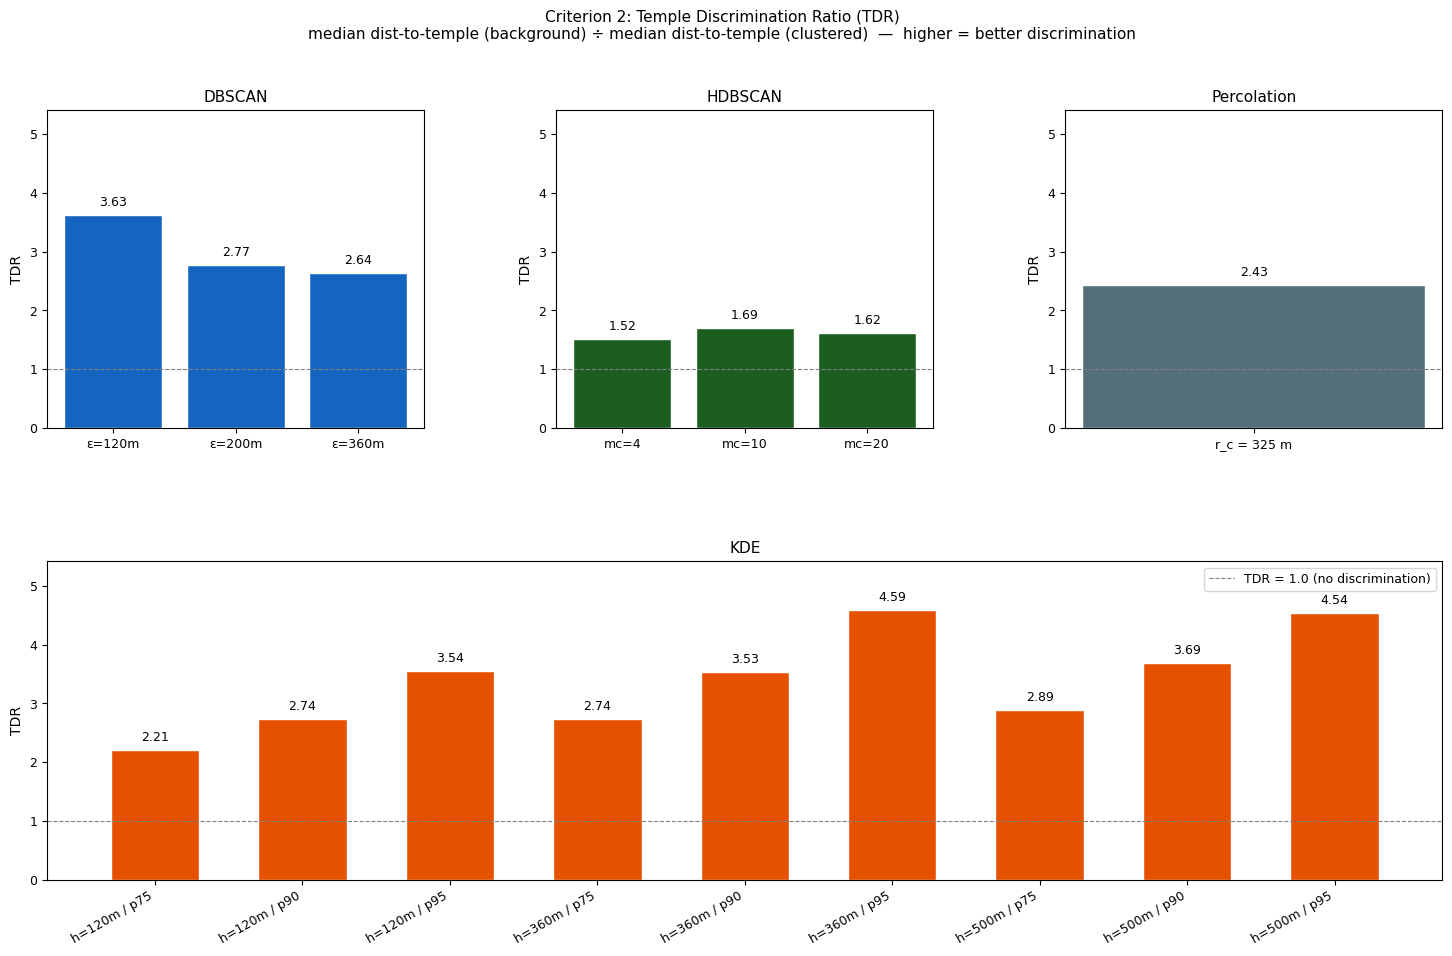

Saved: evaluation_temple_ratio.png


In [14]:
# ── Fig: TDR by method and parameter ───────────────────────────────
# Dynamic y-limit: headroom above the tallest bar across all methods
all_tdr_vals = ([dbscan_tdr[e] for e in DBSCAN_EPS] +
                [hdbscan_tdr[m] for m in MCS_VALUES] +
                [kde_tdr[(bw, pct)] for bw in BANDWIDTHS for pct in PERCENTILES] +
                [perc_tdr])
ylim_top = max(all_tdr_vals) * 1.18

# Layout: top row = DBSCAN | HDBSCAN | Percolation
#         bottom row = KDE spanning full width
fig = plt.figure(figsize=(18, 10))
gs  = fig.add_gridspec(2, 3, hspace=0.42, wspace=0.35)
ax_db   = fig.add_subplot(gs[0, 0])
ax_hdb  = fig.add_subplot(gs[0, 1])
ax_perc = fig.add_subplot(gs[0, 2])
ax_kde  = fig.add_subplot(gs[1, :])   # full-width bottom panel

COL = {'DBSCAN': '#1565C0', 'HDBSCAN': '#1B5E20',
       'KDE': '#E65100', 'Percolation': '#546E7A'}

def annotate_bars(ax, bars, vals):
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + ylim_top * 0.02,
                f'{v:.2f}', ha='center', va='bottom', fontsize=9)

# DBSCAN
bars = ax_db.bar([f'ε={e}m' for e in DBSCAN_EPS],
                 [dbscan_tdr[e] for e in DBSCAN_EPS],
                 color=COL['DBSCAN'], edgecolor='white')
annotate_bars(ax_db, bars, [dbscan_tdr[e] for e in DBSCAN_EPS])
ax_db.axhline(1.0, color='grey', linestyle='--', linewidth=0.8)
ax_db.set_ylim(0, ylim_top)
ax_db.set_title('DBSCAN', fontsize=11)
ax_db.set_ylabel('TDR', fontsize=10)
ax_db.tick_params(labelsize=9)

# HDBSCAN
bars = ax_hdb.bar([f'mc={m}' for m in MCS_VALUES],
                  [hdbscan_tdr[m] for m in MCS_VALUES],
                  color=COL['HDBSCAN'], edgecolor='white')
annotate_bars(ax_hdb, bars, [hdbscan_tdr[m] for m in MCS_VALUES])
ax_hdb.axhline(1.0, color='grey', linestyle='--', linewidth=0.8)
ax_hdb.set_ylim(0, ylim_top)
ax_hdb.set_title('HDBSCAN', fontsize=11)
ax_hdb.set_ylabel('TDR', fontsize=10)
ax_hdb.tick_params(labelsize=9)

# Percolation
bars = ax_perc.bar([f'r_c = {r_c:.0f} m'], [perc_tdr],
                   color=COL['Percolation'], edgecolor='white')
annotate_bars(ax_perc, bars, [perc_tdr])
ax_perc.axhline(1.0, color='grey', linestyle='--', linewidth=0.8)
ax_perc.set_ylim(0, ylim_top)
ax_perc.set_title('Percolation', fontsize=11)
ax_perc.set_ylabel('TDR', fontsize=10)
ax_perc.tick_params(labelsize=9)

# KDE — full-width bottom panel gives room for all 9 bars
kde_lbls = [f'h={bw}m / p{pct}' for bw in BANDWIDTHS for pct in PERCENTILES]
kde_vals = [kde_tdr[(bw, pct)] for bw in BANDWIDTHS for pct in PERCENTILES]
xpos     = np.arange(len(kde_lbls))
bars     = ax_kde.bar(xpos, kde_vals, color=COL['KDE'], edgecolor='white', width=0.6)
annotate_bars(ax_kde, bars, kde_vals)
ax_kde.set_xticks(xpos)
ax_kde.set_xticklabels(kde_lbls, fontsize=9, rotation=30, ha='right')
ax_kde.axhline(1.0, color='grey', linestyle='--', linewidth=0.8,
               label='TDR = 1.0 (no discrimination)')
ax_kde.set_ylim(0, ylim_top)
ax_kde.set_title('KDE', fontsize=11)
ax_kde.set_ylabel('TDR', fontsize=10)
ax_kde.tick_params(labelsize=9)
ax_kde.legend(fontsize=9, loc='upper right')

fig.suptitle(
    'Criterion 2: Temple Discrimination Ratio (TDR)\n'
    'median dist-to-temple (background) ÷ median dist-to-temple (clustered)  —  higher = better discrimination',
    fontsize=11)
plt.savefig(OUT + 'evaluation_temple_ratio.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: evaluation_temple_ratio.png')

## 4. Parameter Stability (Coefficient of Variation)

CV% = (std / mean) × 100 of the percentage of mounds classified as clustered across
all tested parameter settings for a given method. Lower CV = more stable results.

Percolation is excluded.

In [15]:
# DBSCAN stability
dbscan_pct = np.array([
    100 * (DBSCAN_LABELS[eps] != -1).mean() for eps in DBSCAN_EPS
])
cv_dbscan = 100 * dbscan_pct.std() / dbscan_pct.mean()
print(f'DBSCAN  — % clustered: {dbscan_pct.round(1).tolist()}  CV={cv_dbscan:.1f}%')

# HDBSCAN stability
hdbscan_pct = np.array([
    100 * (HDBSCAN_CL[mcs].labels_ != -1).mean() for mcs in MCS_VALUES
])
cv_hdbscan = 100 * hdbscan_pct.std() / hdbscan_pct.mean()
print(f'HDBSCAN — % clustered: {hdbscan_pct.round(1).tolist()}  CV={cv_hdbscan:.1f}%')

# KDE stability (all 9 bandwidth/threshold combinations)
kde_pct_all = np.array([kde_pct[(bw, pct)] for bw in BANDWIDTHS for pct in PERCENTILES])
cv_kde = 100 * kde_pct_all.std() / kde_pct_all.mean()
print(f'KDE     — % in zone:   {kde_pct_all.round(1).tolist()}')
print(f'         CV={cv_kde:.1f}%')

DBSCAN  — % clustered: [32.6, 72.0, 95.6]  CV=38.9%
HDBSCAN — % clustered: [61.8, 58.4, 53.2]  CV=6.1%
KDE     — % in zone:   [99.8, 67.8, 45.1, 83.1, 52.6, 35.1, 80.1, 50.1, 33.4]
         CV=35.9%


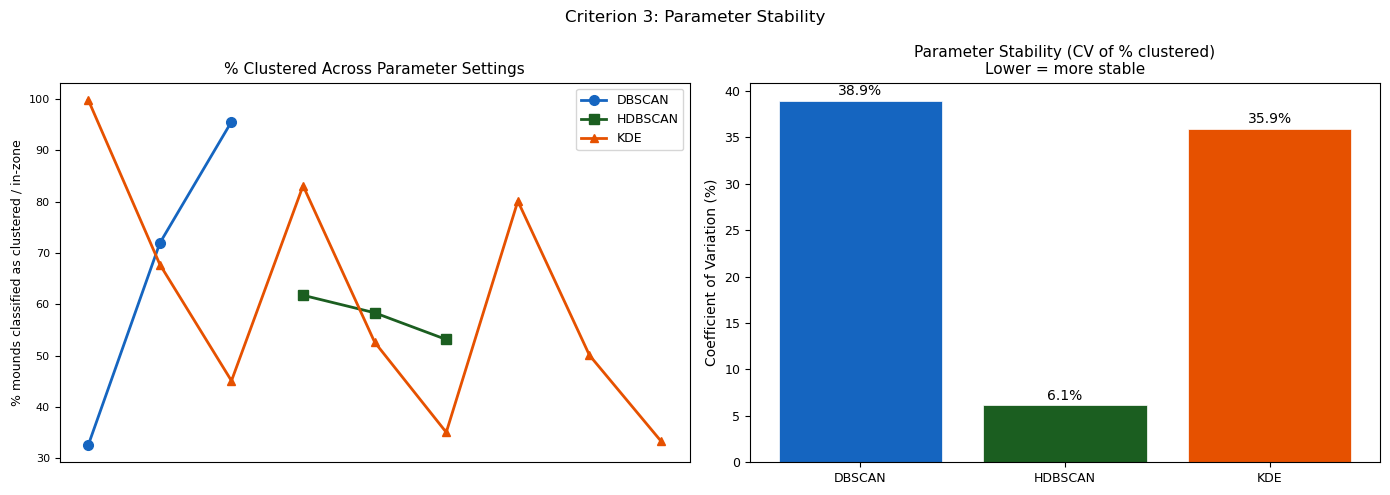

Saved: evaluation_stability.png


In [17]:
# ── Fig: Stability comparison ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: % clustered across parameter settings
ax = axes[0]
ax.plot([f'ε={e}m' for e in DBSCAN_EPS], dbscan_pct, 'o-',
        color='#1565C0', linewidth=2, markersize=7, label='DBSCAN')
ax.plot([f'mc={m}' for m in MCS_VALUES], hdbscan_pct, 's-',
        color='#1B5E20', linewidth=2, markersize=7, label='HDBSCAN')
kde_x = [f'h={bw}\np{pct}' for bw in BANDWIDTHS for pct in PERCENTILES]
ax.plot(range(len(kde_x)), kde_pct_all, '^-',
        color='#E65100', linewidth=2, markersize=6, label='KDE')
ax.set_ylabel('% mounds classified as clustered / in-zone', fontsize=9)
ax.set_title('% Clustered Across Parameter Settings', fontsize=11)
ax.tick_params(labelsize=8); ax.legend(fontsize=9)
ax.set_xticks([])

# Right: CV bar chart
ax = axes[1]
methods = ['DBSCAN', 'HDBSCAN', 'KDE']
cvs     = [cv_dbscan, cv_hdbscan, cv_kde]
colours = ['#1565C0', '#1B5E20', '#E65100']
bars    = ax.bar(methods, cvs, color=colours, edgecolor='white', linewidth=0.5)
for bar, cv in zip(bars, cvs):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{cv:.1f}%', ha='center', va='bottom', fontsize=10)
ax.set_ylabel('Coefficient of Variation (%)', fontsize=10)
ax.set_title('Parameter Stability (CV of % clustered)\nLower = more stable', fontsize=11)
ax.tick_params(labelsize=9)

plt.suptitle('Criterion 3: Parameter Stability', fontsize=12)
plt.tight_layout()
plt.savefig(OUT + 'evaluation_stability.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: evaluation_stability.png')

## 5. Multi-Criteria Summary Table

Each row represents one method-parameter combination. DBCV scores are shown where applicable.
TDR is shown for all methods. CV% is shown at the method level (not per parameter).

In [18]:
rows = []

# DBSCAN
for eps in DBSCAN_EPS:
    labels = DBSCAN_LABELS[eps]
    pct_cl = 100*(labels != -1).mean()
    rows.append({'Method': 'DBSCAN', 'Parameter': f'ε = {eps} m',
                 'DBCV': f'{DBSCAN_DBCV[eps]:.3f}' if not np.isnan(DBSCAN_DBCV[eps]) else 'NaN',
                 'TDR': f'{dbscan_tdr[eps]:.2f}',
                 '% Clustered': f'{pct_cl:.1f}%',
                 'Param. CV%': f'{cv_dbscan:.1f}%'})

# HDBSCAN
for mcs in MCS_VALUES:
    labels = HDBSCAN_CL[mcs].labels_
    pct_cl = 100*(labels != -1).mean()
    rows.append({'Method': 'HDBSCAN', 'Parameter': f'mc = {mcs}',
                 'DBCV': f'{HDBSCAN_DBCV[mcs]:.3f}',
                 'TDR': f'{hdbscan_tdr[mcs]:.2f}',
                 '% Clustered': f'{pct_cl:.1f}%',
                 'Param. CV%': f'{cv_hdbscan:.1f}%'})

# KDE
for bw in BANDWIDTHS:
    for pct in PERCENTILES:
        rows.append({'Method': 'KDE', 'Parameter': f'h={bw}m, p{pct}',
                     'DBCV': 'N/A',
                     'TDR': f'{kde_tdr[(bw,pct)]:.2f}',
                     '% Clustered': f'{kde_pct[(bw,pct)]:.1f}%',
                     'Param. CV%': f'{cv_kde:.1f}%'})

# Percolation
rows.append({'Method': 'Percolation', 'Parameter': f'r_c = {r_c:.0f} m',
             'DBCV': 'N/A',
             'TDR': f'{perc_tdr:.2f}',
             '% Clustered': f'{in_giant.mean()*100:.1f}%',
             'Param. CV%': 'N/A'})

df = pd.DataFrame(rows)
print(df.to_string(index=False))

     Method   Parameter   DBCV  TDR % Clustered Param. CV%
     DBSCAN   ε = 120 m  0.080 3.63       32.6%      38.9%
     DBSCAN   ε = 200 m -0.061 2.77       72.0%      38.9%
     DBSCAN   ε = 360 m -0.611 2.64       95.6%      38.9%
    HDBSCAN      mc = 4  0.195 1.52       61.8%       6.1%
    HDBSCAN     mc = 10  0.275 1.69       58.4%       6.1%
    HDBSCAN     mc = 20  0.243 1.62       53.2%       6.1%
        KDE h=120m, p75    N/A 2.21       99.8%      35.9%
        KDE h=120m, p90    N/A 2.74       67.8%      35.9%
        KDE h=120m, p95    N/A 3.54       45.1%      35.9%
        KDE h=360m, p75    N/A 2.74       83.1%      35.9%
        KDE h=360m, p90    N/A 3.53       52.6%      35.9%
        KDE h=360m, p95    N/A 4.59       35.1%      35.9%
        KDE h=500m, p75    N/A 2.89       80.1%      35.9%
        KDE h=500m, p90    N/A 3.69       50.1%      35.9%
        KDE h=500m, p95    N/A 4.54       33.4%      35.9%
Percolation r_c = 325 m    N/A 2.43       75.2%        N

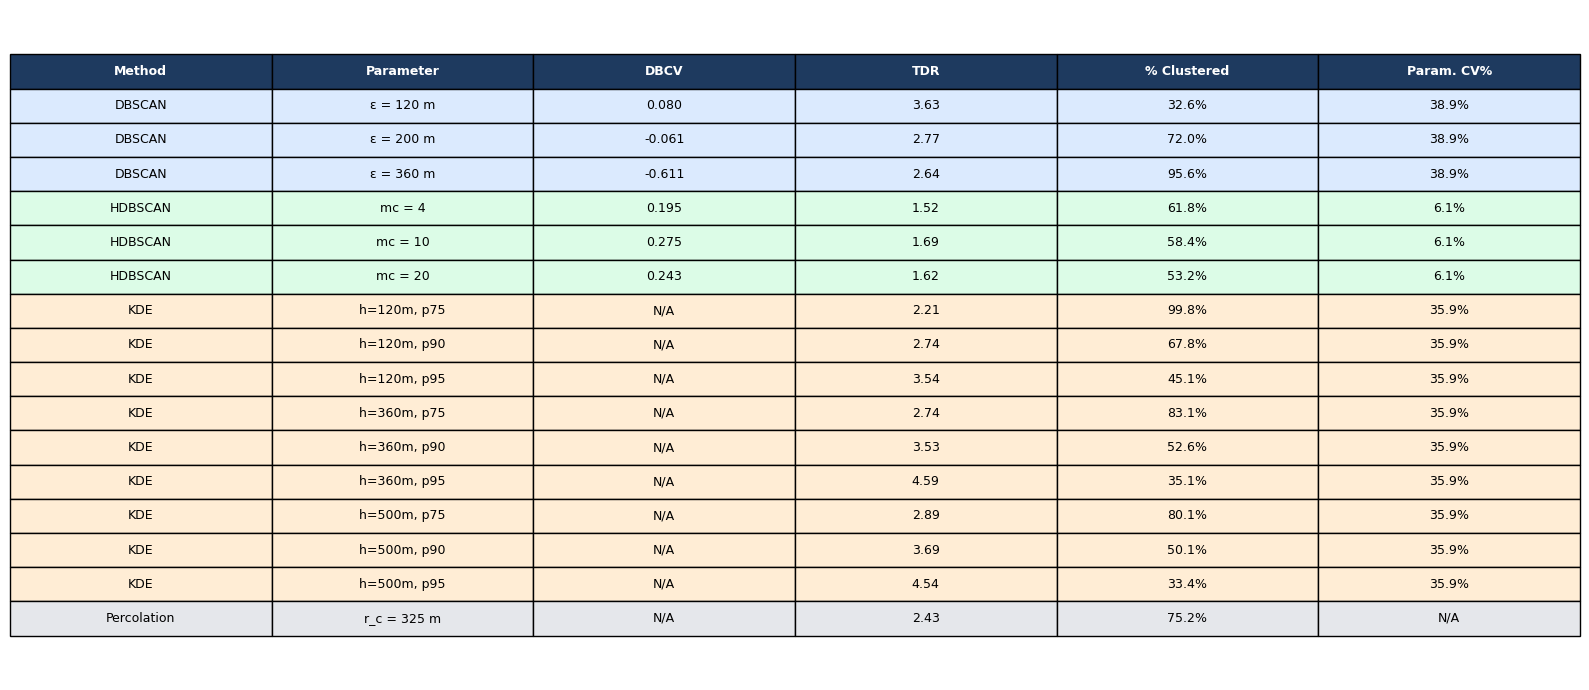

Saved: evaluation_summary_table.png


In [19]:
# ── Render summary table as figure ──────────────────────────────────
col_labels = ['Method', 'Parameter', 'DBCV', 'TDR', '% Clustered', 'Param. CV%']
cell_text  = [[r['Method'], r['Parameter'], r['DBCV'], r['TDR'],
               r['% Clustered'], r['Param. CV%']] for r in rows]

# Row colours by method
method_colours = {
    'DBSCAN':      '#DBEAFE',
    'HDBSCAN':     '#DCFCE7',
    'KDE':         '#FFEDD5',
    'Percolation': '#E5E7EB',
}

fig, ax = plt.subplots(figsize=(16, 7))
ax.axis('off')
tbl = ax.table(cellText=cell_text, colLabels=col_labels,
               loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.65)

# Header
for j in range(len(col_labels)):
    tbl[(0, j)].set_facecolor('#1E3A5F')
    tbl[(0, j)].set_text_props(color='white', fontweight='bold')

# Row shading by method
for i, r in enumerate(rows, start=1):
    col = method_colours.get(r['Method'], 'white')
    for j in range(len(col_labels)):
        tbl[(i, j)].set_facecolor(col)

# Highlight best TDR per method group (highest ratio)
# (visual accent only — do not over-interpret as a ranking)

plt.tight_layout()
plt.savefig(OUT + 'evaluation_summary_table.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: evaluation_summary_table.png')